## Engine Lifetime Analysis

#### Objective

The purpose of this notebook is to analyze the lifetime of each engine in the NASA CMAPSS training dataset.

Specifically, we aim to answer the following questions:

- How many engines are included?
- How many operating cycles does each engine have?
- What is the distribution of engine lifetimes?
- Are engine lifetimes consistent or highly variable?
- Are there any outlier engines?

The findings from this analysis will help guide future preprocessing and sequence modeling decisions.

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

A:\AI Engineer in the way\ML Projects\Predictive-Maintenance-RUL


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from src.data.loader import DataLoader
from src.data.validator import DataValidator

from src.config.config import (
    TRAIN_DATA_PATH,
    TEST_DATA_PATH,
    RUL_DATA_PATH
)

In [4]:
loader = DataLoader(
    TRAIN_DATA_PATH,
    TEST_DATA_PATH,
    RUL_DATA_PATH
)

train_df = loader.load_train()
test_df = loader.load_test()
rul_df = loader.load_rul()

validator = DataValidator(
    train_df,
    test_df,
    rul_df
)

validator.validate_all()

2026-07-18 22:27:37 | INFO | loader.py | Line:18 | Reading train_FD004.txt
2026-07-18 22:27:39 | INFO | loader.py | Line:21 | train_FD004.txt Loaded Successfully
2026-07-18 22:27:39 | INFO | loader.py | Line:18 | Reading test_FD004.txt
2026-07-18 22:27:40 | INFO | loader.py | Line:21 | test_FD004.txt Loaded Successfully
2026-07-18 22:27:40 | INFO | loader.py | Line:18 | Reading RUL_FD004.txt
2026-07-18 22:27:40 | INFO | loader.py | Line:21 | RUL_FD004.txt Loaded Successfully
2026-07-18 22:27:40 | INFO | validator.py | Line:40 | Validating training dataset...
2026-07-18 22:27:40 | INFO | validator.py | Line:50 | Validating testing dataset...
2026-07-18 22:27:40 | INFO | validator.py | Line:60 | Validating RUL dataset...


{'train': {'valid': True, 'errors': [], 'warnings': []},
 'test': {'valid': True, 'errors': [], 'warnings': []},
 'rul': {'valid': True, 'errors': [], 'warnings': ['Duplicate rows found.']}}

### Compute Engine Lifetimes

In [5]:
engine_lifetimes = (
    train_df
    .groupby("unit_number")["time_in_cycles"]
    .max()
)

engine_lifetimes.head()

unit_number
1    321
2    299
3    307
4    274
5    193
Name: time_in_cycles, dtype: int64

In [6]:
## Basic Statistics
engine_lifetimes.describe()

count    249.00000
mean     245.97992
std       73.11080
min      128.00000
25%      190.00000
50%      234.00000
75%      290.00000
max      543.00000
Name: time_in_cycles, dtype: float64

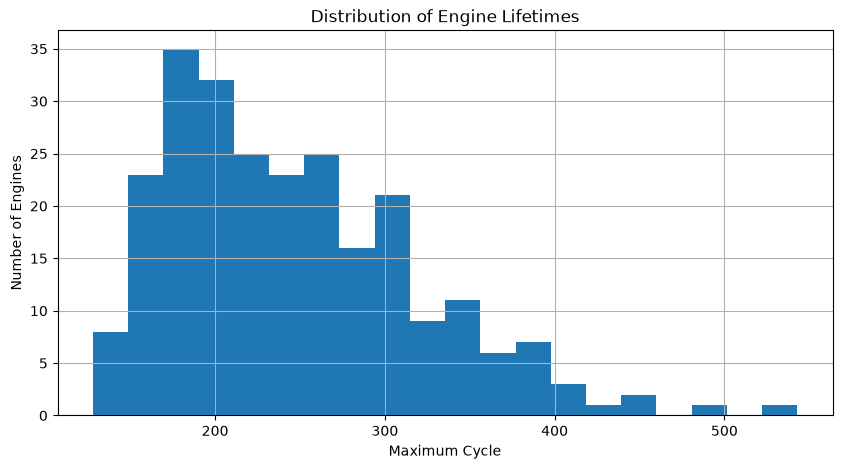

In [7]:
plt.figure(figsize=(10,5))

plt.hist( engine_lifetimes, bins=20)
plt.title("Distribution of Engine Lifetimes")
plt.xlabel("Maximum Cycle")
plt.ylabel("Number of Engines")
plt.grid(True)
plt.show()

Are most engines similar? No, there is a wide variation in lifetimes. The maximum cycles range from around 128 to over 543, though a large concentration sits between 150 and 300 cycles.

Is the distribution skewed? Yes, it is heavily right-skewed (positively skewed), with a long tail extending toward the higher maximum cycles on the right side.


C:\Users\MF\AppData\Local\Temp\ipykernel_29084\2662911884.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


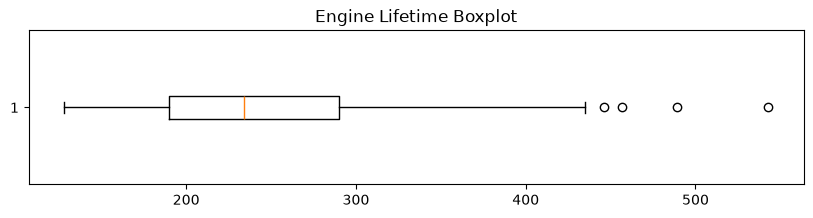

In [ ]:
plt.figure(figsize=(10,2))

plt.boxplot(engine_lifetimes,vert=False)
plt.title("Engine Lifetime Boxplot")
plt.show()

Outliers? Yes, there are several statistical outliers present on the right side of the distribution, indicated by the individual data points plotted beyond the upper whisker.

Extremely short-lived engines? No, there are no outliers on the lower end. The shortest-lived engines fall within the normal expected range calculated by the lower whisker (around 130 cycles).

Extremely long-lived engines? Yes, the outliers represent exceptionally long-lived engines. There are 4 distinct outlier engines that lasted beyond roughly 440 cycles, with the most extreme individual engine reaching nearly 550 cycles.

In [ ]:
## Shortest-Living Engines
engine_lifetimes.sort_values().head(10)

unit_number
214    128
115    131
181    134
156    139
36     143
194    145
211    146
77     148
135    149
150    149
Name: time_in_cycles, dtype: int64

In [ ]:
## Percentiles
engine_lifetimes.quantile(
    [0.25,0.5,0.75,0.9,0.95,0.99]
)

0.25    190.00
0.50    234.00
0.75    290.00
0.90    347.80
0.95    379.00
0.99    451.72
Name: time_in_cycles, dtype: float64

# Observations

## Engine Lifetime Distribution

- The dataset contains engines with significantly different operational lifetimes.
- Engine lifetimes range from approximately **130 cycles** to more than **540 cycles**.
- Most engines fail between **150 and 300 cycles**, indicating this is the most common operating range.

## Distribution Shape

- The lifetime distribution is **positively (right) skewed**.
- A small number of engines survive substantially longer than the majority of the fleet.

## Clustering

- The distribution appears **unimodal**.
- No evidence of multiple operating populations or distinct engine groups was observed based on lifetime alone.

## Outlier Analysis

- Several long-lived engines are identified as statistical outliers (greater than approximately 440 cycles).
- No unusually short-lived engines were detected.
- Since these outliers represent valid engine behavior rather than data errors, they should be retained for future analysis.

# Engineering Decisions

## Decision 1 — Preserve All Engines

Although several engines exhibit exceptionally long operational lifetimes, they appear to be legitimate observations rather than data quality issues.

**Action:** No engines will be removed during preprocessing.

---

## Decision 2 — Variable-Length Sequences

Engine lifetimes vary considerably across the dataset.

**Action:** Future sequence-based models (e.g., LSTM) will require a strategy to handle variable-length sequences, such as sliding windows or sequence padding.

---

## Decision 3 — Per-Engine Target Generation

Because each engine reaches failure after a different number of cycles, Remaining Useful Life (RUL) cannot be derived from a global maximum cycle count.

**Action:** RUL will be computed independently for each engine during preprocessing.

---

## Decision 4 — No Lifetime-Based Filtering

The observed variation in engine lifetimes reflects the natural degradation process of the fleet.

**Action:** Engine lifetime will not be used as a criterion for filtering observations.

---

## Decision 5 — Continue Sensor Investigation

The variability in engine lifetimes suggests that different degradation patterns may exist across engines.

**Action:** The next stage of the EDA will focus on identifying which sensors capture these degradation patterns and contribute meaningful predictive information.